In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datasets import load_dataset
import cv2

import timm
import torch.nn as nn
import copy
import time
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder_path = "/content/drive/Shareddrives/CIS5190_final_project/processed_dataset_grouped"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os
from PIL import Image
from tqdm import tqdm

local_path = "/content/dataset"

# Copy from Shared Drive to local SSD
if not os.path.exists(local_path):
    print("Copying dataset to local storage...")
    shutil.copytree(folder_path, local_path)
    print("Done!")
else:
    print("Local copy already exists, skipping.")

# Shrink oversized images to max 512px (one-time)
for split in ["train", "validation", "test"]:
    split_dir = os.path.join(local_path, split)
    files = [f for f in os.listdir(split_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    resized = 0
    for fname in tqdm(files, desc=f"Resizing {split}"):
        fpath = os.path.join(split_dir, fname)
        try:
            img = Image.open(fpath)
            if max(img.size) > 512:
                img.thumbnail((512, 512))
                img.save(fpath, quality=90)
                resized += 1
        except Exception as e:
            print(f"  Skipped {fname}: {e}")
    print(f"  {split}: resized {resized}/{len(files)} images")

Copying dataset to local storage...
Done!


Resizing train: 100%|██████████| 2304/2304 [05:26<00:00,  7.06it/s]


  train: resized 2304/2304 images


Resizing validation: 100%|██████████| 494/494 [01:11<00:00,  6.93it/s]


  validation: resized 494/494 images


Resizing test: 100%|██████████| 494/494 [01:10<00:00,  7.05it/s]

  test: resized 494/494 images


In [ ]:

dataset = load_dataset("imagefolder", data_dir=local_path)

Resolving data files:   0%|          | 0/2305 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/495 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/495 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
# load data
train_lats = np.array(dataset["train"]["Latitude"], dtype=np.float64)
train_lons = np.array(dataset["train"]["Longitude"], dtype=np.float64)

# compute GPS normalization stats from train, excluding val & test
lat_mean, lat_std = float(train_lats.mean()), float(train_lats.std())
lon_mean, lon_std = float(train_lons.mean()), float(train_lons.std())


In [ ]:
# functions & variables used for normalization the GPS data
# normalizing The dataset to zero mean
def normalize_gps(lat, lon):
    lat_n = (lat - lat_mean) / lat_std
    lon_n = (lon - lon_mean) / lon_std
    return lat_n, lon_n

# revert normalization to use when doing predictions.
def denormalize_gps(lat_n, lon_n):
    lat = lat_n * lat_std + lat_mean
    lon = lon_n * lon_std + lon_mean
    return lat, lon



In [ ]:
# preprocessing part

# steps:
# 1. resize to 256, then random crop to 224
# 2. slight random rotation
# 3. augmentations on color/lighting/blur/grayscale
# 5. ImageNet normalization
# 6. convert to tensor

train_process = A.Compose([
    # resize to 256 with same ratio:
    A.SmallestMaxSize(max_size=256),
    # random crop to 224x224:
    A.RandomResizedCrop(size=(224,224), scale=[0.8,1], p=1, ratio=[0.9,1.1]), # might need to change the ratio here later
    # random rotation, very slight
    A.Rotate(limit=12, p = 0.3, border_mode=cv2.BORDER_REFLECT_101), # set border_mode to have no black corner
    # small perspective warps. handles tilt differences between collectors
    A.Perspective(scale=(0.02, 0.05), p=0.3, pad_mode=cv2.BORDER_REFLECT_101),
    # brightness, contrast, satuartion, all using a very modest num. Might need to change saturation since testing data has more trees(greener)?
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.3, hue=0.08, p= 0.6),
    # lightning, mild changes to small portion of data
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p = 0.3),
    # dealing with contrast, normalize lighting differences, mild changes to small portion of data
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    # random shadow, set min_y to 0.2 bc putting shadow to top part(usually sky) is kinda unrealistic. Very modest changes
    A.RandomShadow(shadow_roi=(0, 0.2, 1, 1), num_shadows_limit=(1, 2), p=0.2),
    # random gray scale, to learn building structures better
    A.ToGray(p=0.1),
    # coarse dropout. don't let the model lean on a single patch of the frame
    A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(16, 48), hole_width_range=(16, 48), p=0.3),
    # ImageNet normalization using constants
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # to pytorch tensor
    ToTensorV2()

])

# just resize to 224x224 by resize + crop at center + normalization with ImageNet constants
val_test_process = A.Compose([
    A.SmallestMaxSize(max_size=256),
    A.CenterCrop(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [ ]:
# process the data
def make_fn(aug_process):
    def process_batch(batch):
        processed_images = []

        for pil_img in batch["image"]:
            img_np = np.array(pil_img.convert("RGB"))   # PIL -> NumPy
            img_out = aug_process(image=img_np)["image"]  # augment
            processed_images.append(img_out)

        lat = np.array(batch["Latitude"], dtype=np.float32)
        lon = np.array(batch["Longitude"], dtype=np.float32)

        lat = (lat - lat_mean) / lat_std
        lon = (lon - lon_mean) / lon_std

        labels = torch.tensor(np.stack([lat, lon], axis=1), dtype=torch.float32)

        return {
            "pixel_values": torch.stack(processed_images),
            "labels": labels,
        }

    return process_batch

train_ds = dataset["train"].with_transform(make_fn(train_process))
val_ds   = dataset["validation"].with_transform(make_fn(val_test_process))
test_ds  = dataset["test"].with_transform(make_fn(val_test_process))


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=1, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=1, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=1, pin_memory=True)

# Sanity check
batch = next(iter(train_loader))
print(f"pixel_values: {batch['pixel_values'].shape}")
print(f"labels:       {batch['labels'].shape}")

pixel_values: torch.Size([64, 3, 224, 224])
labels:       torch.Size([64, 2])


In [ ]:
test_loader

In [ ]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [ ]:
def train_model(model, model_name, num_epochs=30, lr_backbone=1e-4, lr_head=1e-3):
    model = model.to(device)

    # Discriminative LR: small for pretrained backbone, larger for new head
    head_params = []
    backbone_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(kw in name for kw in ["classifier", "fc", "head"]):
            head_params.append(param)
        else:
            backbone_params.append(param)

    print(f"  Backbone params: {sum(p.numel() for p in backbone_params):,}")
    print(f"  Head params:     {sum(p.numel() for p in head_params):,}")

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone, "weight_decay": 0.05},
        {"params": head_params,     "lr": lr_head,     "weight_decay": 0.01},
    ])
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": [], "val_haversine": []}
    best_haversine = float("inf")
    best_weights = None

    print(f"\n{'='*60}")
    print(f"  Training: {model_name} for {num_epochs} epochs")
    print(f"{'='*60}")
    start = time.time()

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        n = 0
        for batch in train_loader:
            imgs = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            n += imgs.size(0)

        train_loss = running_loss / n

        # ---- Validate ----
        model.eval()
        val_loss_sum = 0.0
        all_preds, all_actuals = [], []
        n_val = 0

        with torch.no_grad():
            for batch in val_loader:
                imgs = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)

                out = model(imgs)
                val_loss_sum += criterion(out, labels).item() * imgs.size(0)
                n_val += imgs.size(0)

                preds_np = out.cpu().numpy()
                labels_np = labels.cpu().numpy()
                p_lat, p_lon = denormalize_gps(preds_np[:, 0], preds_np[:, 1])
                t_lat, t_lon = denormalize_gps(labels_np[:, 0], labels_np[:, 1])
                all_preds.append(np.stack([p_lat, p_lon], axis=1))
                all_actuals.append(np.stack([t_lat, t_lon], axis=1))

        val_loss = val_loss_sum / n_val
        all_preds = np.concatenate(all_preds)
        all_actuals = np.concatenate(all_actuals)
        dists = haversine_m(all_actuals[:,0], all_actuals[:,1],
                            all_preds[:,0],   all_preds[:,1])
        avg_hav = dists.mean()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_haversine"].append(avg_hav)

        marker = ""
        if avg_hav < best_haversine:
            best_haversine = avg_hav
            best_weights = copy.deepcopy(model.state_dict())
            marker = " ★"

        scheduler.step()

        print(f"  Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"Haversine: {avg_hav:.1f}m (med {np.median(dists):.1f}m){marker}")

    elapsed = time.time() - start
    print(f"\n  Done in {elapsed/60:.1f} min | Best: {best_haversine:.1f}m")

    model.load_state_dict(best_weights)
    return model, history, best_haversine

In [ ]:
import matplotlib.pyplot as plt

resnet18  = timm.create_model("resnet18",       pretrained=True, num_classes=2)
effnet_b0 = timm.create_model("efficientnet_b0", pretrained=True, num_classes=2)

print(f"ResNet-18:       {sum(p.numel() for p in resnet18.parameters()):>10,} params")
print(f"EfficientNet-B0: {sum(p.numel() for p in effnet_b0.parameters()):>10,} params")

NUM_EPOCHS = 30

resnet_model,  resnet_hist,  resnet_best  = train_model(resnet18,  "ResNet-18",       NUM_EPOCHS)
effnet_model,  effnet_hist,  effnet_best  = train_model(effnet_b0, "EfficientNet-B0", NUM_EPOCHS)

ResNet-18:       11,177,538 params
EfficientNet-B0:  4,010,110 params
  Backbone params: 11,176,512
  Head params:     1,026

  Training: ResNet-18 for 30 epochs
  Epoch  1/30 | Train: 0.9322 | Val: 1.1271 | Haversine: 82.1m (med 79.2m) ★
  Epoch  2/30 | Train: 0.7772 | Val: 1.0287 | Haversine: 75.9m (med 70.5m) ★
  Epoch  3/30 | Train: 0.6269 | Val: 0.8577 | Haversine: 66.8m (med 61.6m) ★
  Epoch  4/30 | Train: 0.4979 | Val: 0.8386 | Haversine: 64.8m (med 58.3m) ★
  Epoch  5/30 | Train: 0.4281 | Val: 0.7811 | Haversine: 61.6m (med 53.7m) ★
  Epoch  6/30 | Train: 0.3643 | Val: 0.7279 | Haversine: 58.8m (med 51.4m) ★
  Epoch  7/30 | Train: 0.3379 | Val: 0.6772 | Haversine: 56.8m (med 49.1m) ★
  Epoch  8/30 | Train: 0.3017 | Val: 0.7431 | Haversine: 59.6m (med 50.9m)
  Epoch  9/30 | Train: 0.2792 | Val: 0.6473 | Haversine: 54.6m (med 47.0m) ★
  Epoch 10/30 | Train: 0.2507 | Val: 0.6398 | Haversine: 54.1m (med 45.7m) ★
  Epoch 11/30 | Train: 0.2299 | Val: 0.6429 | Haversine: 54.3m (med 45

In [ ]:
convnext_t  = timm.create_model("convnext_tiny.fb_in22k_ft_in1k", pretrained=True, num_classes=2)
print(f"ConvNeXt-Tiny:   {sum(p.numel() for p in convnext_t.parameters()):>10,} params")
convnext_model, convnext_hist, convnext_best = train_model(convnext_t, "ConvNeXt-Tiny", NUM_EPOCHS)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

ConvNeXt-Tiny:   27,821,666 params
  Backbone params: 1,906,944
  Head params:     25,914,722

  Training: ConvNeXt-Tiny for 30 epochs
  Epoch  1/30 | Train: 2.2297 | Val: 1.3800 | Haversine: 90.1m (med 81.4m) ★
  Epoch  2/30 | Train: 0.8030 | Val: 0.8705 | Haversine: 66.7m (med 59.2m) ★
  Epoch  3/30 | Train: 0.5061 | Val: 0.6943 | Haversine: 53.9m (med 46.2m) ★
  Epoch  4/30 | Train: 0.2572 | Val: 0.5751 | Haversine: 45.0m (med 38.2m) ★
  Epoch  5/30 | Train: 0.1376 | Val: 0.4949 | Haversine: 40.1m (med 31.0m) ★
  Epoch  6/30 | Train: 0.0840 | Val: 0.4319 | Haversine: 34.9m (med 27.3m) ★
  Epoch  7/30 | Train: 0.0618 | Val: 0.4089 | Haversine: 32.2m (med 24.4m) ★
  Epoch  8/30 | Train: 0.0498 | Val: 0.5257 | Haversine: 39.5m (med 32.0m)
  Epoch  9/30 | Train: 0.0503 | Val: 0.4255 | Haversine: 33.6m (med 26.0m)
  Epoch 10/30 | Train: 0.0288 | Val: 0.3976 | Haversine: 31.2m (med 22.7m) ★
  Epoch 11/30 | Train: 0.0224 | Val: 0.3733 | Haversine: 29.8m (med 22.5m) ★
  Epoch 12/30 | Train:

In [ ]:
effnet_b3   = timm.create_model("efficientnet_b3", pretrained=True, num_classes=2)
print(f"EfficientNet-B3: {sum(p.numel() for p in effnet_b3.parameters()):>10,} params")
effb3_model,    effb3_hist,    effb3_best    = train_model(effnet_b3,  "EfficientNet-B3", NUM_EPOCHS)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet-B3: 10,699,306 params
  Backbone params: 10,106,408
  Head params:     592,898

  Training: EfficientNet-B3 for 30 epochs
  Epoch  1/30 | Train: 9.9465 | Val: 7.3726 | Haversine: 219.9m (med 204.4m) ★
  Epoch  2/30 | Train: 4.7884 | Val: 3.8898 | Haversine: 158.7m (med 145.1m) ★
  Epoch  3/30 | Train: 2.1174 | Val: 2.1744 | Haversine: 116.5m (med 108.0m) ★


KeyboardInterrupt: 

In [ ]:
def evaluate_test(model, model_name):
    model.eval()
    all_preds, all_actuals = [], []

    with torch.no_grad():
        for batch in test_loader:
            imgs = batch["pixel_values"].to(device)
            labels = batch["labels"]

            out = model(imgs).cpu().numpy()
            labels_np = labels.numpy()

            p_lat, p_lon = denormalize_gps(out[:, 0], out[:, 1])
            t_lat, t_lon = denormalize_gps(labels_np[:, 0], labels_np[:, 1])
            all_preds.append(np.stack([p_lat, p_lon], axis=1))
            all_actuals.append(np.stack([t_lat, t_lon], axis=1))

    all_preds = np.concatenate(all_preds)
    all_actuals = np.concatenate(all_actuals)
    dists = haversine_m(all_actuals[:,0], all_actuals[:,1],
                        all_preds[:,0],   all_preds[:,1])

    print(f"\n  {model_name} — Test Results:")
    print(f"    Mean:   {dists.mean():.1f} m")
    print(f"    Median: {np.median(dists):.1f} m")
    print(f"    <10m:   {(dists<10).mean()*100:.1f}%")
    print(f"    <25m:   {(dists<25).mean()*100:.1f}%")
    print(f"    <50m:   {(dists<50).mean()*100:.1f}%")

    return dists, all_preds, all_actuals

resnet_dists,  resnet_preds,  resnet_actuals  = evaluate_test(resnet_model,  "ResNet-18")
effnet_dists,  effnet_preds,  effnet_actuals  = evaluate_test(effnet_model,  "EfficientNet-B0")
convnext_dists, convnext_preds, convnext_actuals = evaluate_test(convnext_model, "ConvNeXt-Tiny")
# effb3_dists,    effb3_preds,    effb3_actuals    = evaluate_test(effb3_model,    "EfficientNet-B3")



  ResNet-18 — Test Results:
    Mean:   51.5 m
    Median: 44.4 m
    <10m:   3.8%
    <25m:   23.7%
    <50m:   56.3%

  EfficientNet-B0 — Test Results:
    Mean:   56.9 m
    Median: 51.9 m
    <10m:   2.8%
    <25m:   17.2%
    <50m:   47.6%

  ConvNeXt-Tiny — Test Results:
    Mean:   30.1 m
    Median: 21.0 m
    <10m:   19.4%
    <25m:   58.3%
    <50m:   83.8%


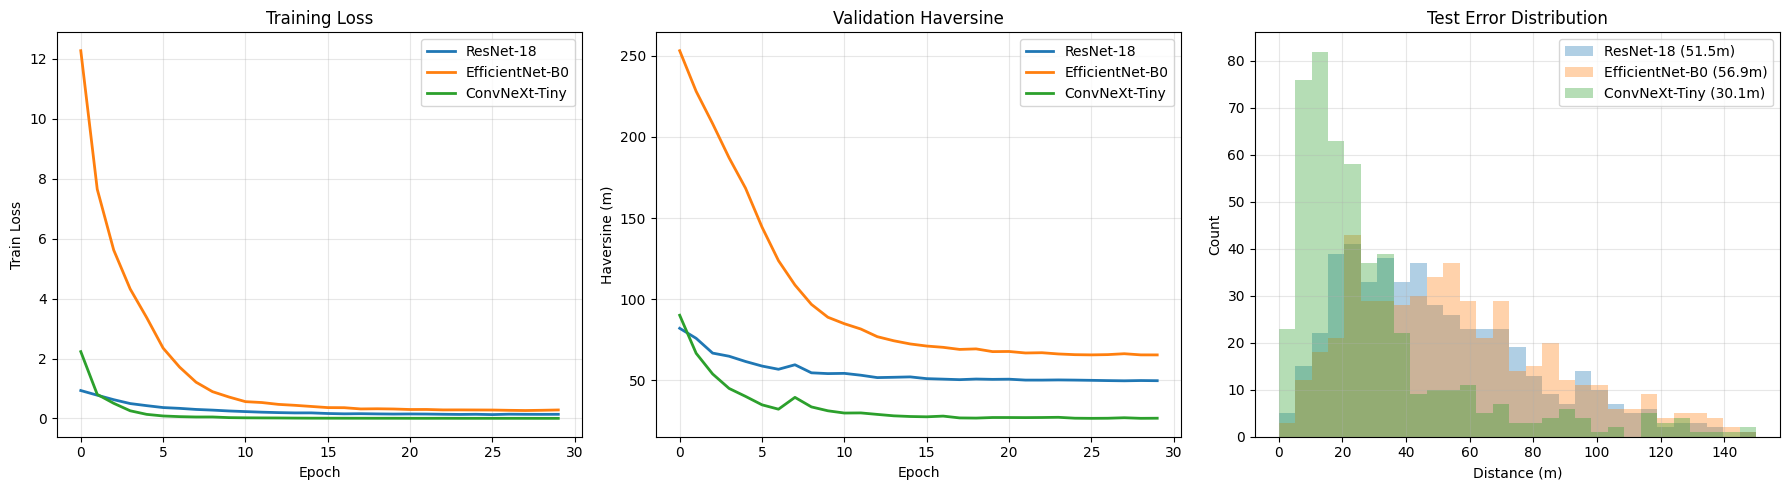

In [ ]:
models_data = [
    ("ResNet-18",       resnet_hist,   resnet_dists,   resnet_preds,   resnet_actuals,   resnet_model,   resnet_best),
    ("EfficientNet-B0", effnet_hist,    effnet_dists,    effnet_preds,    effnet_actuals,    effnet_model,    effnet_best),
    # ("EfficientNet-B3", effb3_hist,    effb3_dists,    effb3_preds,    effb3_actuals,    effb3_model,    effb3_best),
    ("ConvNeXt-Tiny",   convnext_hist, convnext_dists, convnext_preds, convnext_actuals, convnext_model, convnext_best),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, hist, dists, _, _, _, _ in models_data:
    axes[0].plot(hist["train_loss"], label=name, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss")
axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

for name, hist, dists, _, _, _, _ in models_data:
    axes[1].plot(hist["val_haversine"], label=name, linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Haversine (m)")
axes[1].set_title("Validation Haversine"); axes[1].legend(); axes[1].grid(alpha=0.3)

bins = np.linspace(0, 150, 30)
for name, _, dists, _, _, _, _ in models_data:
    axes[2].hist(dists, bins=bins, alpha=0.35, label=f"{name} ({dists.mean():.1f}m)")
axes[2].set_xlabel("Distance (m)"); axes[2].set_ylabel("Count")
axes[2].set_title("Test Error Distribution"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

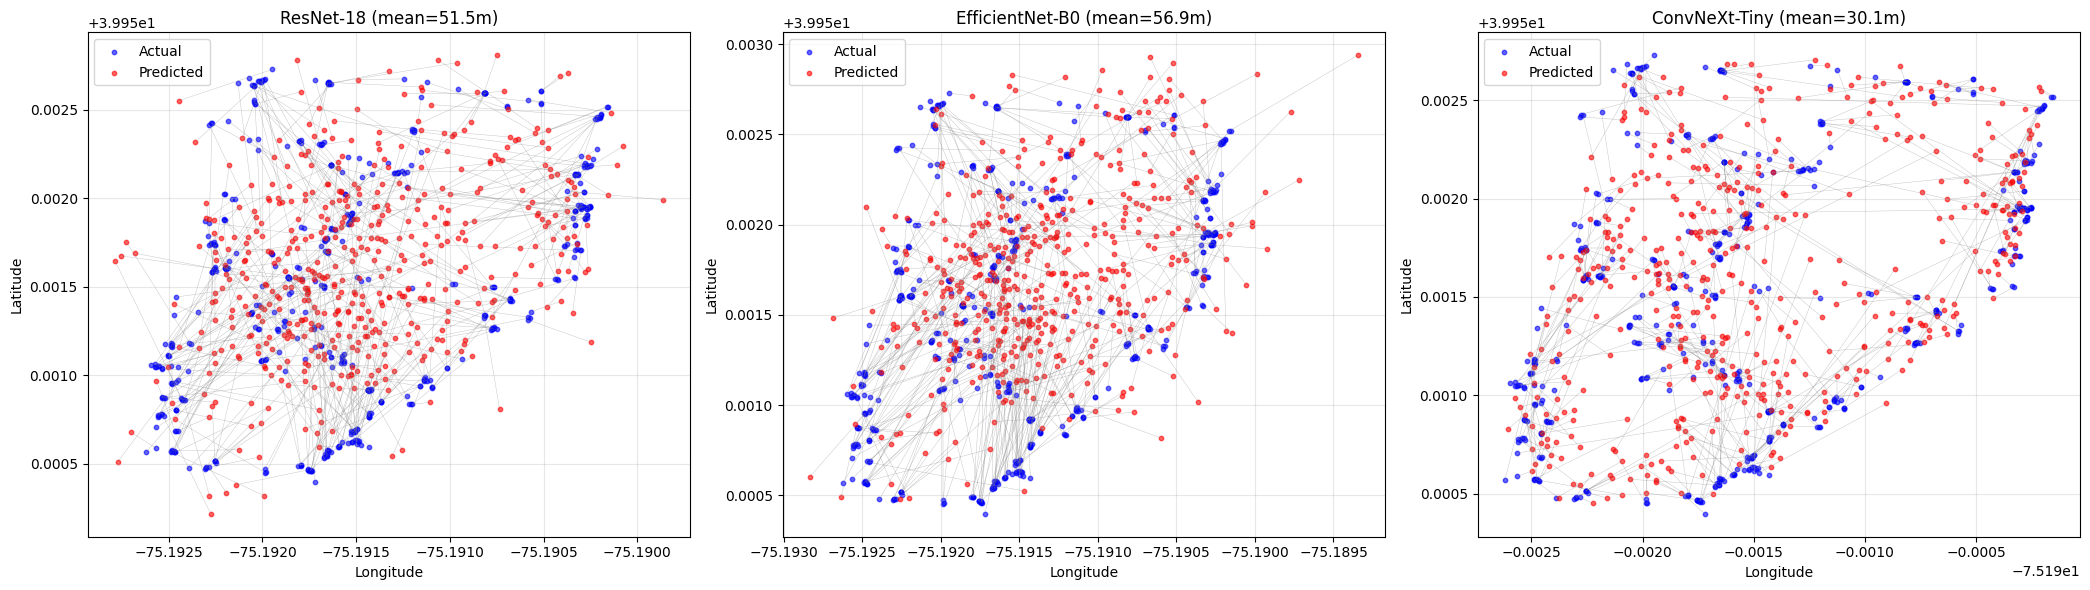

In [ ]:
models_data = [
    ("ResNet-18",       resnet_hist,   resnet_dists,   resnet_preds,   resnet_actuals,   resnet_model,   resnet_best),
    ("EfficientNet-B0", effnet_hist,    effnet_dists,    effnet_preds,    effnet_actuals,    effnet_model,    effnet_best),
    ("ConvNeXt-Tiny",   convnext_hist, convnext_dists, convnext_preds, convnext_actuals, convnext_model, convnext_best),
]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (name, hist, dists, preds, actuals, model, best) in zip(axes, models_data):
    ax.scatter(actuals[:,1], actuals[:,0], c="blue", s=10, alpha=0.6, label="Actual")
    ax.scatter(preds[:,1],   preds[:,0],   c="red",  s=10, alpha=0.6, label="Predicted")
    for i in range(len(actuals)):
        ax.plot([actuals[i,1], preds[i,1]], [actuals[i,0], preds[i,0]],
                color="gray", linewidth=0.3, alpha=0.5)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"{name} (mean={dists.mean():.1f}m)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()